Import all the useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


### Import Data 

Import all the formatted .csv files. (These .csv files have been formatted and cleaned manually from the PDF files provided by the client using tools such as Adobe Express and OCR tools provided by Muckrock)

The database structure is given below :-
- data
    - Financial Statements
        - Financial Statements Format-1.csv
        - Financial Statements Format-2 Europe.csv
        - Financial Statements Format-2 Korea.csv
        - Financial Statements Format-2 Japan.csv
        - Financial Statements Format-3 Europe.csv
        - Financial Statements Format-3 Korea.csv
        - Financial Statements Format-3 Japan.csv
        - Financial Statements Format-4.csv
    - Navy Revenue
        - Navy Revenue Report FY16-FY24-1 Format 1.csv
        - Navy Revenue Report FY20-FY24-1 Format 2.csv
    - Marine Revenue
        - Marine Revenue FY20-FY24 Format 1.csv
        - Marine Revenue FY20-FY24 Format 2.csv
    - bases.json


In [2]:
# State file paths
# Financial Statements
financial_statements_1_path = 'data/Financial Statements/Financial Statements Format-1.csv'
financial_statements_2_europe_path = 'data/Financial Statements/Financial Statements Format-2 Europe.csv'
financial_statements_2_korea_path = 'data/Financial Statements/Financial Statements Format-2 Korea.csv'
financial_statements_2_japan_path = 'data/Financial Statements/Financial Statements Format-2 Japan.csv'
financial_statements_3_europe_path = 'data/Financial Statements/Financial Statements Format-3 Europe.csv'
financial_statements_3_korea_path = 'data/Financial Statements/Financial Statements Format-3 Korea.csv'
financial_statements_3_japan_path = 'data/Financial Statements/Financial Statements Format-3 Japan.csv'
financial_statements_4_path = 'data/Financial Statements/Financial Statements Format-4.csv'

# Navy Revenue
navy_revenue_1_path = 'data/Navy Revenue/Navy Revenue Report FY16-FY24-1 Format 1.csv'
navy_revenue_2_path = 'data/Navy Revenue/Navy Revenue Report FY20-FY24-1 Format 2.csv'

# Marine Revenue
marine_revenue_1_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 1.csv'
marine_revenue_2_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 2.csv'

# Base Location
bases_file_path = 'data/bases.json'

In [3]:
# Import and read csv files
# Financial Statements
fs1 = pd.read_csv(financial_statements_1_path)
fs2e = pd.read_csv(financial_statements_2_europe_path)
fs2k = pd.read_csv(financial_statements_2_korea_path)
fs2j = pd.read_csv(financial_statements_2_japan_path)
fs3e = pd.read_csv(financial_statements_3_europe_path)
fs3k = pd.read_csv(financial_statements_3_korea_path)
fs3j = pd.read_csv(financial_statements_3_japan_path)
fs4 = pd.read_csv(financial_statements_4_path)

# Navy Revenue
nr1 = pd.read_csv(navy_revenue_1_path)
nr2 = pd.read_csv(navy_revenue_2_path)

# Marine Revenue
mr1 = pd.read_csv(marine_revenue_1_path)
mr2 = pd.read_csv(marine_revenue_2_path)

# Bases Locations
bases = pd.read_json(bases_file_path)

### Financial Statements

#### Analyze and Preprocess

Analyze the database structure for "Financial Statements Format-1.csv" from the variable 'fs1'

In [4]:
fs1

,Details,Current Balance,Month,Year,Type
0,Cash--Operating,"2,38,22,204.63",March,2023,Asset
1,Cash--Restricted,"1,54,48,852.84",March,2023,Asset
2,Accounts Receivable,"2,61,378.56",March,2023,Asset
3,Prepaid Expenses,"3,43,049.36",March,2023,Asset
4,Fixed Assets,"4,43,71,000.09",March,2023,Asset
...,...,...,...,...,...
728,Accrued Salaries,"3,86,900.61",December,2023,Liability
729,Accrued Leave Payable,"5,52,778.73",December,2023,Liability
730,Total Liabilities,"61,79,771.03",December,2023,Liability
731,EQUITY,"4,52,32,973.04",December,2023,Liability


It seems like that there are 733 rows with 5 columns. Checking for all the unique values in the 'Details' attribute.

In [5]:
fs1["Details"].unique()

array(['Cash--Operating', 'Cash--Restricted', 'Accounts Receivable',
       'Prepaid Expenses', 'Fixed Assets', 'Less Accum Depreciation',
       'TOTAL ASSETS                                  ',
       'Accounts Payable', 'Distributions Payable', 'Accrued Liabilities',
       'Accrued Salaries', 'Accrued Leave Payable', 'Total Liabilities',
       'EQUITY', 'TOTAL LIABILITIES & EQUITY', 'Cash', 'TOTAL ASSETS',
       'Less Accum Pepreciation', 'LIABILITIES',
       'Total Liabilities EQUITY', 'Accounts   Receivable',
       'Prepaid   Expenses', 'Fixed   Assets',
       'Less  Accum   Depreciation', 'TOTAL   ASSETS',
       'Accounts   Payable', 'Distributions   Payable',
       'Accrued   Liabilities', 'Accrued   Salaries',
       'Accrued   Leave   Payable', 'Total   Liabilities',
       'TOTAL   LIABILITIES   &   EQUITY', 'Less   Accum   Depreciation',
       'Accru.ed Liabilities', 'Accru.ed Salaries',
       'Accru.ed Leave Payable', 'Cash--Operating ',
       'Less Accum Depreci

It seems like there are some case sensitive errors where same values like "Accrued Liabilities" are having different names like "Accrued   Liabilities" and "Accru.ed Liabilities" (typing mistakes)(Probably happened while performing OCR using Adobe Express).

From these values, the Unique Values should be :-
- Cash--Operating
- Cash--Restricted
- Accounts Receivable
- Prepaid Expenses
- Fixed Assets
- Less Accum Depreciation
- TOTAL ASSETS
- Accounts Payable
- Distributions Payable
- Accrued Liabilities
- Accrued Salaries
- Accrued Leave Payable
- Total Liabilities
- EQUITY
- TOTAL LIABILITIES & EQUITY

We need to format that


In [6]:
# List of desired unique values
desired_values = [
    'Cash--Operating', 'Cash--Restricted', 'Accounts Receivable',
    'Prepaid Expenses', 'Fixed Assets', 'Less Accum Depreciation',
    'TOTAL ASSETS',
    'Accounts Payable', 'Distributions Payable', 'Accrued Liabilities',
    'Accrued Salaries', 'Accrued Leave Payable', 'Total Liabilities',
    'EQUITY', 'TOTAL LIABILITIES & EQUITY'
]

# Function to normalize each entry
def normalize_value(val):
    if pd.isna(val):
        return val
    val = val.strip()  # Remove leading/trailing spaces
    val = ' '.join(val.split())  # Replace multiple spaces with single
    val = val.replace('.', '')  # Remove any dots
    # Match closest desired value
    for d in desired_values:
        if val.lower() == d.lower():
            return d
    return val  # If no match, keep as is

# Apply normalization to the 'Details' column
fs1['Details'] = fs1['Details'].apply(normalize_value)

# Check unique values now
print(fs1['Details'].unique())


['Cash--Operating' 'Cash--Restricted' 'Accounts Receivable'
 'Prepaid Expenses' 'Fixed Assets' 'Less Accum Depreciation'
 'TOTAL ASSETS' 'Accounts Payable' 'Distributions Payable'
 'Accrued Liabilities' 'Accrued Salaries' 'Accrued Leave Payable'
 'Total Liabilities' 'EQUITY' 'TOTAL LIABILITIES & EQUITY' 'Cash'
 'Less Accum Pepreciation' 'LIABILITIES' 'Total Liabilities EQUITY']


Now, the values have been formatted

Since there were issues in Financial Statements Format-1, we need to check Format-4. Visualizing Format-4 Data below.

In [7]:
fs4

,Locations,March Europe,March Korea,March Japan,YTD\nEurope,YTD\nKorea,YTD\nJapan,Month,Year
0,Kaiserslautern,"4,35,381.00",0.00,0.00,"17,69,195.35",0.00,0.00,March,2023
1,Grafenwoehr,"1,48,145.60",0.00,0.00,"8,27,100.45",0.00,0.00,March,2023
2,Wiesbaden,"2,65,851.45",0.00,0.00,"13,76,947.40",0.00,0.00,March,2023
3,Vicenza,"91,264.15",0.00,0.00,"4,85,232.45",0.00,0.00,March,2023
4,Livorno,"9,019.10",0.00,0.00,"73,555.45",0.00,0.00,March,2023
...,...,...,...,...,...,...,...,...,...
1629,Iwakuni Marines,0.00,0.00,"1,67,680.35",0.00,0.00,"5,35,915.30",December,2023
1630,Sasebo Navy,0.00,0.00,"1,11,517.10",0.00,0.00,"6,51,567.15",December,2023
1631,Yokosuka Navy,0.00,0.00,"3,89,418.85",0.00,0.00,"12,73,000.40",December,2023
1632,Singapore Navy,0.00,0.00,"1,209.70",0.00,0.00,"3,948.20",December,2023


We can see that the financial values are mentioned in form of string and contains commas and spaces. These are first needed to be preprocessed and then converted into float values for further processing and gathering insights.

In [8]:
def formate_value(val):
    if pd.isna(val):
        return val
    val = val.strip()
    val = val.replace('"', '')
    val = val.replace(',', '')
    val = val.replace("-", '')            
    val = val.replace(" ", '')
    val = val.replace("·", '')
    val = float(val)
    return val

def to_string(val):
    if pd.isna(val):
        return val
    val = str(val)
    return val

# Convert Numeric Values
fs4["March Europe"] = fs4["March Europe"].apply(formate_value)
fs4["March Korea"] = fs4["March Korea"].apply(formate_value)
fs4["March Japan"] = fs4["March Japan"].apply(formate_value)
fs4["YTD\nEurope"] = fs4["YTD\nEurope"].apply(formate_value)
fs4["YTD\nKorea"] = fs4["YTD\nKorea"].apply(formate_value)
fs4["YTD\nJapan"] = fs4["YTD\nJapan"].apply(formate_value)

# Convert to date and time
fs4["Year"] = fs4["Year"].apply(to_string)
fs4["MonthYearString"] = fs4["Month"] + ' ' + fs4["Year"]
fs4['Last_Day_Date'] = pd.to_datetime(fs4['MonthYearString'], format="%B %Y") + pd.tseries.offsets.MonthEnd(0)


In [9]:
fs4

,Locations,March Europe,March Korea,March Japan,YTD\nEurope,YTD\nKorea,YTD\nJapan,Month,Year,MonthYearString,Last_Day_Date
0,Kaiserslautern,435381.00,0.00,0.00,1769195.35,0.0,0.00,March,2023,March 2023,2023-03-31
1,Grafenwoehr,148145.60,0.00,0.00,827100.45,0.0,0.00,March,2023,March 2023,2023-03-31
2,Wiesbaden,265851.45,0.00,0.00,1376947.40,0.0,0.00,March,2023,March 2023,2023-03-31
3,Vicenza,91264.15,0.00,0.00,485232.45,0.0,0.00,March,2023,March 2023,2023-03-31
4,Livorno,9019.10,0.00,0.00,73555.45,0.0,0.00,March,2023,March 2023,2023-03-31
...,...,...,...,...,...,...,...,...,...,...,...
1629,Iwakuni Marines,0.00,0.00,167680.35,0.00,0.0,535915.30,December,2023,December 2023,2023-12-31
1630,Sasebo Navy,0.00,0.00,111517.10,0.00,0.0,651567.15,December,2023,December 2023,2023-12-31
1631,Yokosuka Navy,0.00,0.00,389418.85,0.00,0.0,1273000.40,December,2023,December 2023,2023-12-31
1632,Singapore Navy,0.00,0.00,1209.70,0.00,0.0,3948.20,December,2023,December 2023,2023-12-31


Now we can see that we have formatted the financial values and they can be processed effectively.

Adobe Express had the entire data formatted very well for the rest of the data. Let us try to visualize the data.

                 Locations  March Europe  March Korea  March Japan  \
0           Kaiserslautern     435381.00         0.00         0.00   
1              Grafenwoehr     148145.60         0.00         0.00   
2                Wiesbaden     265851.45         0.00         0.00   
3                  Vicenza      91264.15         0.00         0.00   
4                  Livorno       9019.10         0.00         0.00   
...                    ...           ...          ...          ...   
1612           Naples Navy      91870.90         0.00         0.00   
1613        Sigonella Navy      70596.65         0.00         0.00   
1614             Rota Navy      88509.70         0.00         0.00   
1615        Souda Bay Navy      23784.60         0.00         0.00   
1633  Total Gaming Revenue    1230686.37   1517091.14   1787612.95   

      YTD\nEurope  YTD\nKorea  YTD\nJapan     Month  Year MonthYearString  \
0      1769195.35         0.0        0.00     March  2023      March 2023   
1    

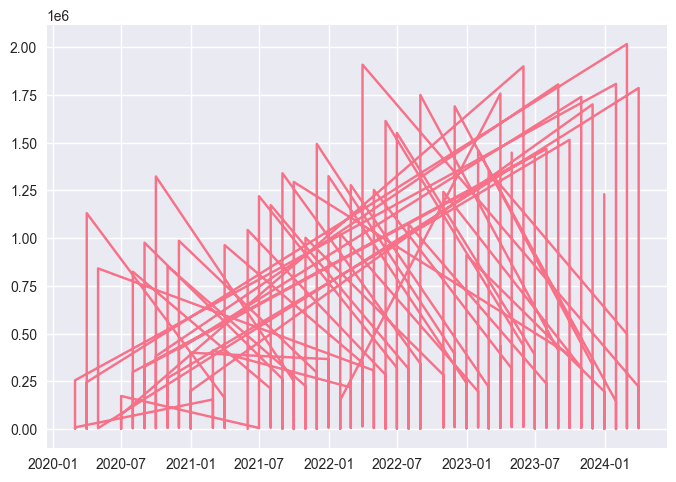

In [10]:
europe_data = fs4[fs4["March Europe"] != 0]
x_value = np.array(europe_data["Last_Day_Date"])
y_value = np.array(europe_data["March Europe"])

print(europe_data)

plt.plot(x_value, y_value)
plt.show()

Not much insightful. We can try further formatting and making functions for plotting. We also got top 10 bases from the analysis on Datasette, which are:-
- Camp Humphreys
- Okinawa Marines
- Yokosuka Navy
- AFRC Dragon Hill Lodge
- Daegu
- Kaiserslautern
- Wiesbaden
- Casey & Hovey
- Sasebo Navy
- Stuttgart

In [11]:
# Define the top 10 bases
TOP_10_BASES = [
    'Camp Humphreys',
    'Okinawa Marines', 
    'Yokosuka Navy',
    'AFRC Dragon Hill Lodge',
    'Daegu',
    'Kaiserslautern',
    'Wiesbaden',
    'Casey & Hovey',
    'Sasebo Navy',
    'Stuttgart'
]

From the data we can clean and categorize it on the basis of the following :-
- Base name
- Currency Value (if there are still any issues in the currency formatting)
- Military Branch
- Region in which the Branch is located:-
    - Europe
    - Korea
    - Japan
    - Singapore
    - Other (If any)
- Monthly Revenue

In [12]:
def clean_base_name(name):
    """Clean and standardize base names by removing extra spaces and standardizing formatting"""
    if pd.isna(name):
        return name
    
    # Remove extra spaces (multiple spaces, tabs, etc.)
    name = re.sub(r'\s+', ' ', str(name).strip())
    
    # Standardize common base name variations
    name = re.sub(r'Camp\s+', 'Camp ', name)
    name = re.sub(r'AFRC\s+', 'AFRC ', name)
    name = re.sub(r'Navy\s*$', 'Navy', name)
    name = re.sub(r'Marines\s*$', 'Marines', name)
    
    # Specific known variations - ensure they match our TOP_10_BASES
    name = name.replace('Casey &   Hovey', 'Casey & Hovey')
    name = name.replace('Casey & Hovey', 'Casey & Hovey')
    name = name.replace('Camp     Humphreys', 'Camp Humphreys')
    name = name.replace('AFRC   Dragon   Hill   Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('AFRC  Dragon  Hill  Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('Sanna Navy', 'Sanno Navy')  # Fix typo
    name = name.replace('Wiesb3den', 'Wiesbaden')  # Fix typo
    name = name.replace('Ansb3ch', 'Ansbach')  # Fix typo
    
    # Ensure base names match our predefined list
    for base in TOP_10_BASES:
        if base.lower() in name.lower():
            return base
    
    return name.strip()

def clean_currency_value(value):
    """Clean and convert currency string to float"""
    if pd.isna(value) or value == '' or value == 0.00:
        return 0.0
    
    # Handle negative values and various formats
    if isinstance(value, str):
        # Remove commas and spaces
        value = value.replace(',', '').replace(' ', '')
        # Handle negative values with parentheses or minus sign
        if '(' in value and ')' in value:
            value = '-' + value.replace('(', '').replace(')', '')
        # Handle trailing minus sign
        if value.endswith('-'):
            value = '-' + value[:-1]
        # Remove any non-numeric characters except decimal point and minus
        value = re.sub(r'[^\d.-]', '', value)
        
        if value == '' or value == '-':
            return 0.0
    
    try:
        return float(value)
    except (ValueError, TypeError):
        return 0.0

def categorize_branch(location):
    """Categorize locations by military branch"""
    location_lower = str(location).lower()
    
    if 'navy' in location_lower:
        return 'Navy'
    elif 'marines' in location_lower:
        return 'Marines'
    elif any(word in location_lower for word in ['army', 'ansbach', 'baumholder', 'grafenwoehr', 'hohenfels', 'wiesbaden']):
        return 'Army'
    elif 'air' in location_lower or 'afrc' in location_lower:
        return 'Air Force'
    else:
        return 'Total'

def categorize_region(location):
    """Categorize locations by geographic region"""
    location_lower = str(location).lower()
    
    if any(word in location_lower for word in ['germany', 'europe', 'kaiserslautern', 'grafenwoehr', 
                                            'wiesbaden', 'vicenza', 'livorno', 'stuttgart', 
                                            'baumholder', 'ansbach', 'schinnen', 'hohenfels',
                                            'naples', 'sigonella', 'rota', 'souda', 'brunssum']):
        return 'Europe'
    elif any(word in location_lower for word in ['korea', 'seoul', 'casey', 'hovey', 'uijongbu', 
                                                'humphreys', 'daegu', 'chinhae', 'mujuk']):
        return 'Korea'
    elif any(word in location_lower for word in ['japan', 'zama', 'fuji', 'sanno', 'atsugi', 
                                                'okinawa', 'iwakuni', 'sasebo', 'yokosuka']):
        return 'Japan'
    elif 'singapore' in location_lower:
        return 'Singapore'
    else:
        return 'Other'

def load_and_clean_data(file_path):
    """Load and clean the financial data"""
    df = pd.read_csv(file_path)
    
    # Clean column names
    df.columns = [col.replace('\n', ' ').strip() for col in df.columns]
    
    # Clean base names first
    df['Locations'] = df['Locations'].apply(clean_base_name)
    
    # Clean monetary columns
    monetary_columns = ['March Europe', 'March Korea', 'March Japan', 
                        'YTD Europe', 'YTD Korea', 'YTD Japan']
    
    for col in monetary_columns:
        df[col] = df[col].apply(clean_currency_value)
    
    # Filter out total rows for base-level analysis
    df = df[~df['Locations'].str.contains('Total', na=False)]
    df = df[~df['Locations'].str.contains('Europe', na=False)]  # Remove summary rows
    
    # Filter to only include our predefined top 10 bases
    df = df[df['Locations'].isin(TOP_10_BASES)]
    
    # Add branch and region categories
    df['Branch'] = df['Locations'].apply(categorize_branch)
    df['Region'] = df['Locations'].apply(categorize_region)
    
    # Create a proper datetime column
    df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))
    
    return df

def create_monthly_revenue_column(df):
    """Create a monthly revenue column by summing across regions"""
    df['Monthly_Revenue'] = df[['March Europe', 'March Korea', 'March Japan']].sum(axis=1)
    df['YTD_Revenue'] = df[['YTD Europe', 'YTD Korea', 'YTD Japan']].sum(axis=1)
    return df

#### Plot and Visualize Data

Since we have preprocessed the data, we can build plotting functions based on :-
- Revenue by Branch and Region
- Revenue of Top Bases Over Time
- Branch Performance Over Time
- Summary

In [13]:
def plot_revenue_by_branch_region(df):
    """Plot total and per-base revenue by branch and region"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Total revenue by branch
    branch_revenue = df.groupby('Branch')['Monthly_Revenue'].sum().sort_values(ascending=False)
    axes[0, 0].bar(branch_revenue.index, branch_revenue.values / 1e6, color='skyblue')
    axes[0, 0].set_title('Total Monthly Revenue by Military Branch', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Revenue (Millions $)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Total revenue by region
    region_revenue = df.groupby('Region')['Monthly_Revenue'].sum().sort_values(ascending=False)
    axes[0, 1].bar(region_revenue.index, region_revenue.values / 1e6, color='lightcoral')
    axes[0, 1].set_title('Total Monthly Revenue by Region', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Revenue (Millions $)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Average per-base revenue by branch
    branch_avg = df.groupby('Branch')['Monthly_Revenue'].mean().sort_values(ascending=False)
    axes[1, 0].bar(branch_avg.index, branch_avg.values / 1e3, color='lightgreen')
    axes[1, 0].set_title('Average Monthly Revenue per Base by Branch', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Revenue (Thousands $)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Average per-base revenue by region
    region_avg = df.groupby('Region')['Monthly_Revenue'].mean().sort_values(ascending=False)
    axes[1, 1].bar(region_avg.index, region_avg.values / 1e3, color='gold')
    axes[1, 1].set_title('Average Monthly Revenue per Base by Region', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Revenue (Thousands $)')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return branch_revenue, region_revenue, branch_avg, region_avg


def plot_top_bases_over_time(df):
    """Plot top bases revenue over time and ranking changes"""
    # Aggregate data by base and year - only for our predefined top 10 bases
    base_year_revenue = df.groupby(['Locations', 'Year'])['Monthly_Revenue'].sum().reset_index()
    
    # Use only our predefined top bases
    top_bases_data = base_year_revenue[base_year_revenue['Locations'].isin(TOP_10_BASES)]
    
    # Plot 1: Revenue trends for top bases
    plt.figure(figsize=(15, 8))
    for base in TOP_10_BASES:
        base_data = top_bases_data[top_bases_data['Locations'] == base]
        if not base_data.empty:
            plt.plot(base_data['Year'], base_data['Monthly_Revenue'] / 1e3, 
                    marker='o', linewidth=2, label=base)
    
    plt.title('Monthly Revenue Trends for Top 10 Bases (2020-2024)', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Monthly Revenue (Thousands $)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Ranking changes by year - FIXED VERSION
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    years = sorted(df['Year'].unique())
    
    # Define colors for different bases
    base_colors = {
        'Camp Humphreys': '#1f77b4',
        'Okinawa Marines': '#ff7f0e',
        'Yokosuka Navy': '#2ca02c',
        'AFRC Dragon Hill Lodge': '#d62728',
        'Daegu': '#9467bd',
        'Kaiserslautern': '#8c564b',
        'Wiesbaden': '#e377c2',
        'Casey & Hovey': '#7f7f7f',
        'Sasebo Navy': '#bcbd22',
        'Stuttgart': '#17becf'
    }
    
    for i, year in enumerate(years[-4:]):  # Last 4 years
        row, col = i // 2, i % 2
        ax = axes[row, col]
        
        year_data = df[df['Year'] == year]
        
        # Get data for all top 10 bases for this year, fill missing with 0
        top_bases_year_data = []
        for base in TOP_10_BASES:
            base_data = year_data[year_data['Locations'] == base]
            if not base_data.empty:
                revenue = base_data['Monthly_Revenue'].iloc[0]
            else:
                revenue = 0  # Base had no revenue this year
            top_bases_year_data.append({'Locations': base, 'Monthly_Revenue': revenue})
        
        top_bases_year = pd.DataFrame(top_bases_year_data)
        top_bases_year = top_bases_year.sort_values('Monthly_Revenue', ascending=True)  # Sort for horizontal bar
        
        # Create positions for bars
        y_pos = np.arange(len(top_bases_year))
        
        # Create bars with appropriate colors
        for j, (idx, row_data) in enumerate(top_bases_year.iterrows()):
            color = base_colors.get(row_data['Locations'], '#17becf')
            bar = ax.barh(y_pos[j], row_data['Monthly_Revenue'] / 1e3, color=color, alpha=0.7, height=0.8)
            
            # Add value labels on bars (only if revenue > 0)
            if row_data['Monthly_Revenue'] > 0:
                ax.text(row_data['Monthly_Revenue'] / 1e3 + 5, y_pos[j], 
                        f'{row_data["Monthly_Revenue"]/1e3:.0f}K', 
                        ha='left', va='center', fontsize=9, fontweight='bold')
        
        # Set y-axis labels (base names)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_bases_year['Locations'].tolist(), fontsize=9)
        
        # Set x-axis limit and labels
        max_revenue = top_bases_year['Monthly_Revenue'].max() / 1e3
        ax.set_xlim(0, max(max_revenue * 1.15, 100))  # Ensure minimum width
        ax.set_xlabel('Monthly Revenue (Thousands $)', fontsize=10)
        ax.set_title(f'Top 10 Bases - {year}', fontsize=12, fontweight='bold')
        
        # Add grid
        ax.grid(True, axis='x', alpha=0.3)
        ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    return top_bases_data

def plot_branch_performance_over_time(df):
    """Plot branch performance over time"""
    branch_year_revenue = df.groupby(['Branch', 'Year'])['Monthly_Revenue'].sum().reset_index()
    
    plt.figure(figsize=(12, 8))
    
    for branch in df['Branch'].unique():
        branch_data = branch_year_revenue[branch_year_revenue['Branch'] == branch]
        plt.plot(branch_data['Year'], branch_data['Monthly_Revenue'] / 1e6, 
                marker='o', linewidth=3, label=branch, markersize=8)
    
    plt.title('Branch Revenue Performance Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Total Monthly Revenue (Millions $)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return branch_year_revenue

def generate_summary_statistics(df):
    """Generate comprehensive summary statistics"""
    print("=" * 60)
    print("SLOT MACHINE REVENUE ANALYSIS SUMMARY")
    print("=" * 60)
    
    # Basic statistics
    total_revenue = df['Monthly_Revenue'].sum()
    avg_revenue_per_base = df['Monthly_Revenue'].mean()
    num_bases = df['Locations'].nunique()
    
    print(f"\nOverall Statistics:")
    print(f"Total Monthly Revenue: ${total_revenue:,.2f}")
    print(f"Average Monthly Revenue per Base: ${avg_revenue_per_base:,.2f}")
    print(f"Number of Unique Bases: {num_bases}")
    
    # Show the predefined top 10 bases
    print(f"\nPredefined Top 10 Bases:")
    for i, base in enumerate(TOP_10_BASES, 1):
        print(f"{i:2d}. {base}")
    
    # Top performing bases from actual data
    print(f"\nTop 10 Bases by Total Revenue (from data):")
    top_bases = df.groupby('Locations')['Monthly_Revenue'].sum().nlargest(10)
    for i, (base, revenue) in enumerate(top_bases.items(), 1):
        print(f"{i:2d}. {base:<25} ${revenue:>12,.2f}")
    
    # Branch analysis
    print(f"\nRevenue by Branch:")
    branch_summary = df.groupby('Branch').agg({
        'Monthly_Revenue': ['sum', 'mean', 'count']
    }).round(2)
    print(branch_summary)
    
    # Region analysis
    print(f"\nRevenue by Region:")
    region_summary = df.groupby('Region').agg({
        'Monthly_Revenue': ['sum', 'mean', 'count']
    }).round(2)
    print(region_summary)


Loading and cleaning data...
SLOT MACHINE REVENUE ANALYSIS SUMMARY

Overall Statistics:
Total Monthly Revenue: $179,023,472.10
Average Monthly Revenue per Base: $380,901.00
Number of Unique Bases: 10

Predefined Top 10 Bases:
 1. Camp Humphreys
 2. Okinawa Marines
 3. Yokosuka Navy
 4. AFRC Dragon Hill Lodge
 5. Daegu
 6. Kaiserslautern
 7. Wiesbaden
 8. Casey & Hovey
 9. Sasebo Navy
10. Stuttgart

Top 10 Bases by Total Revenue (from data):
 1. Camp Humphreys            $41,046,205.31
 2. Okinawa Marines           $40,114,470.65
 3. Yokosuka Navy             $17,531,344.59
 4. AFRC Dragon Hill Lodge    $17,379,871.34
 5. Daegu                     $12,856,565.67
 6. Kaiserslautern            $11,963,664.97
 7. Wiesbaden                 $10,775,545.89
 8. Casey & Hovey             $9,892,056.94
 9. Sasebo Navy               $8,817,638.32
10. Stuttgart                 $8,646,108.42

Revenue by Branch:
          Monthly_Revenue                 
                      sum       mean count
Br

/var/folders/qb/ryzvq_b945z63l6zsksvg3th0000gn/T/ipykernel_48287/1020352199.py:122: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))


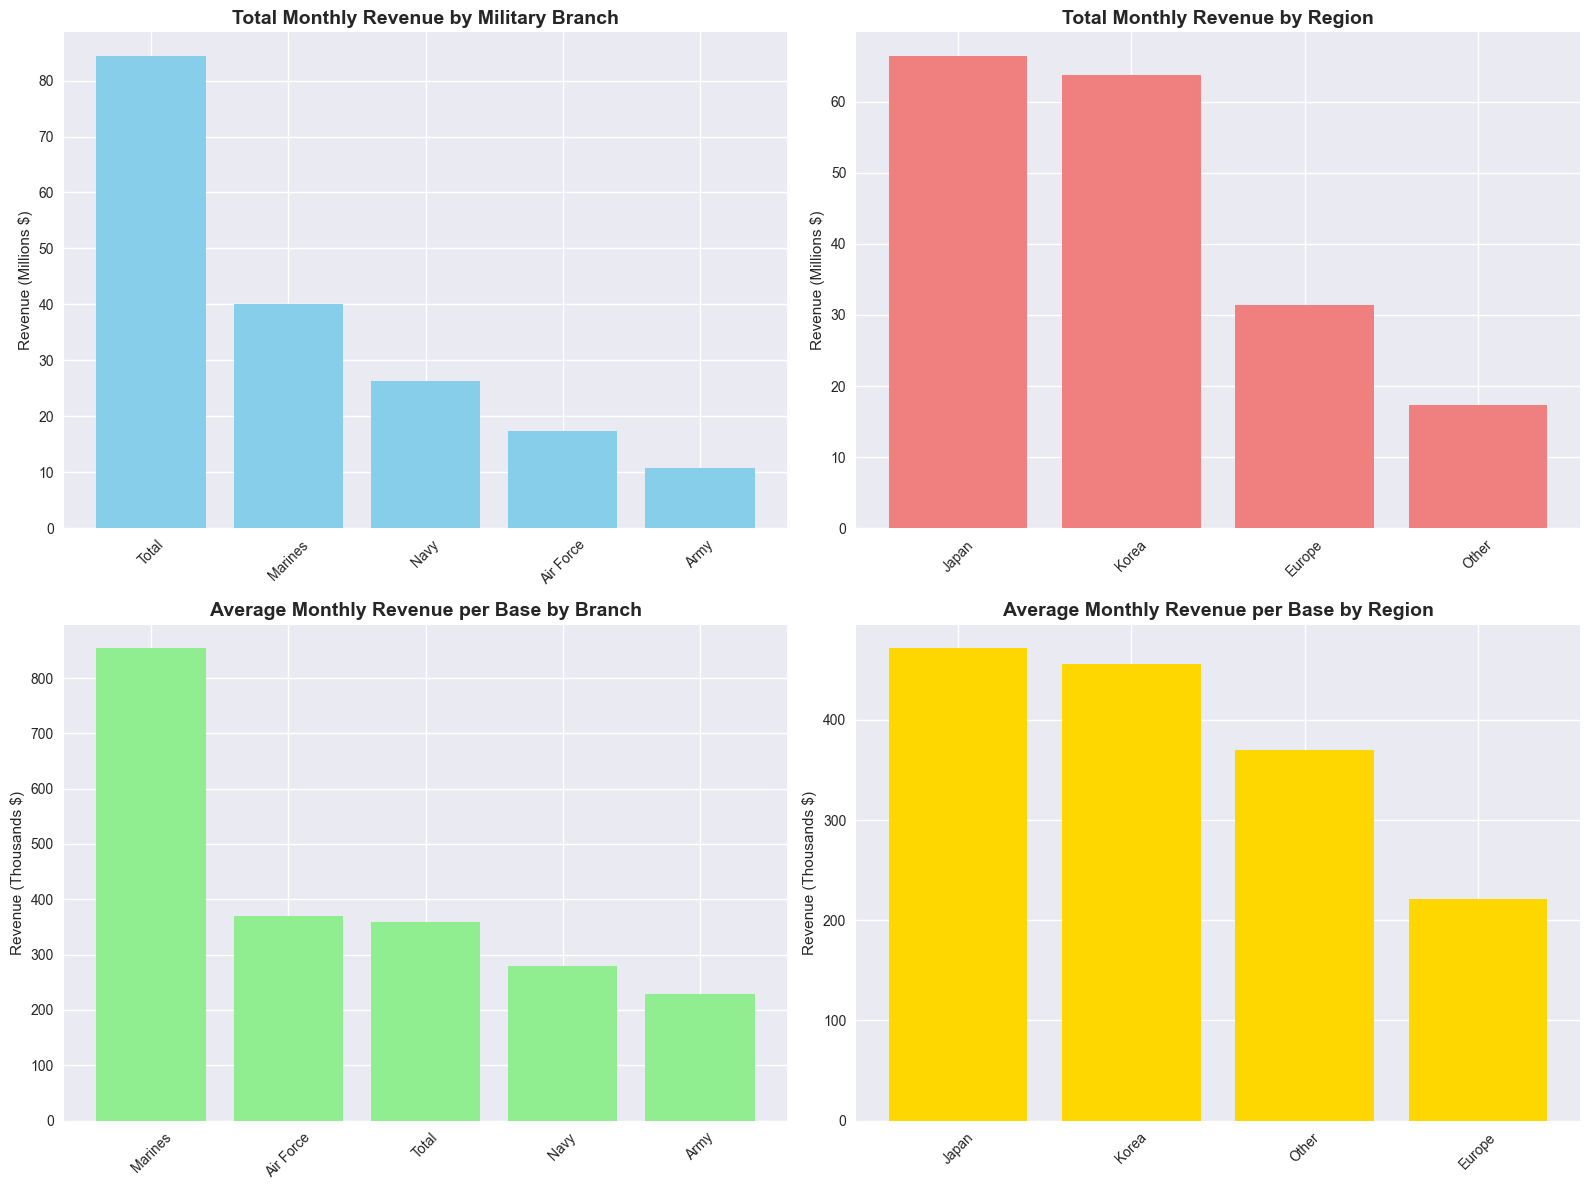

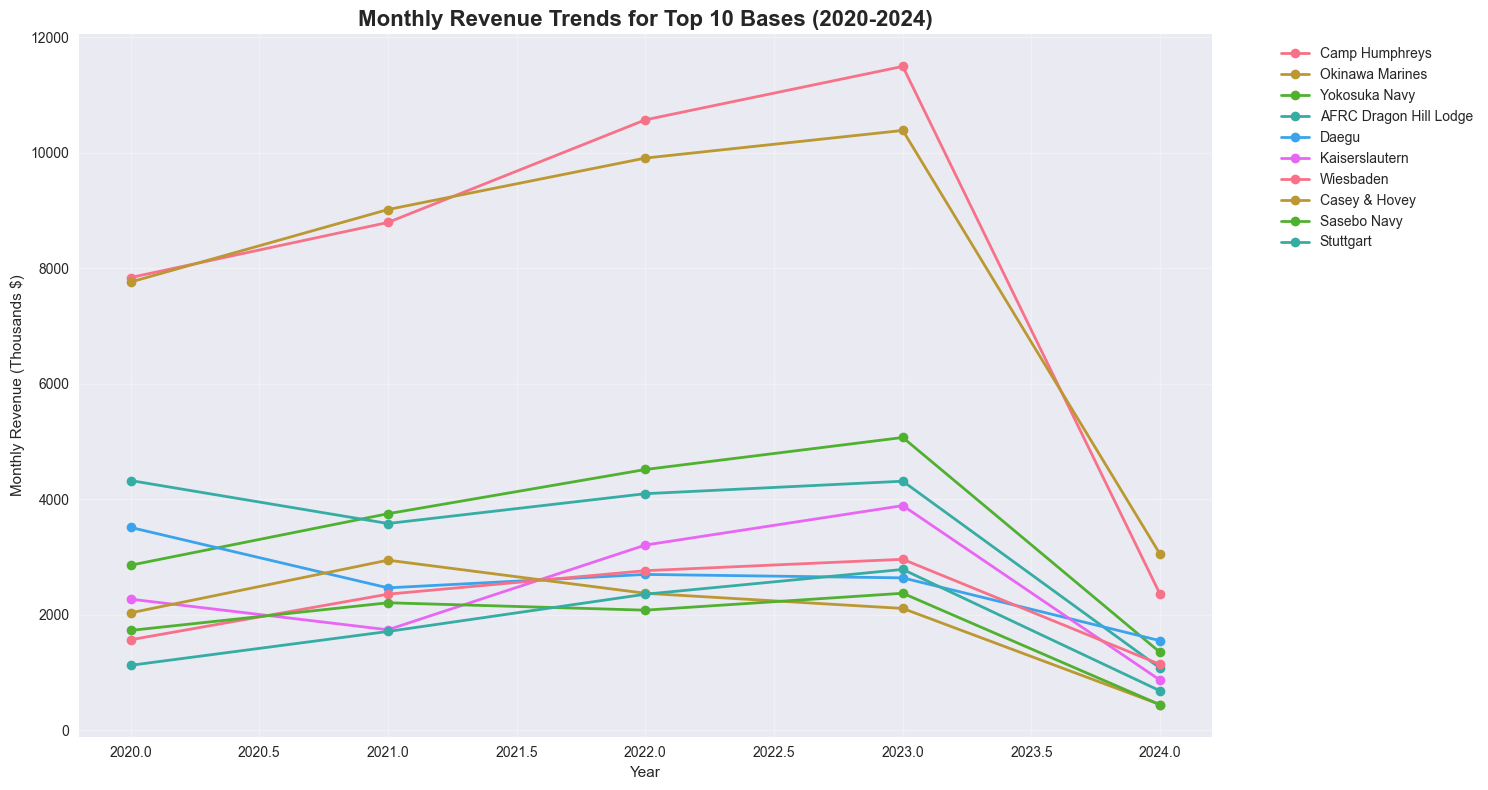

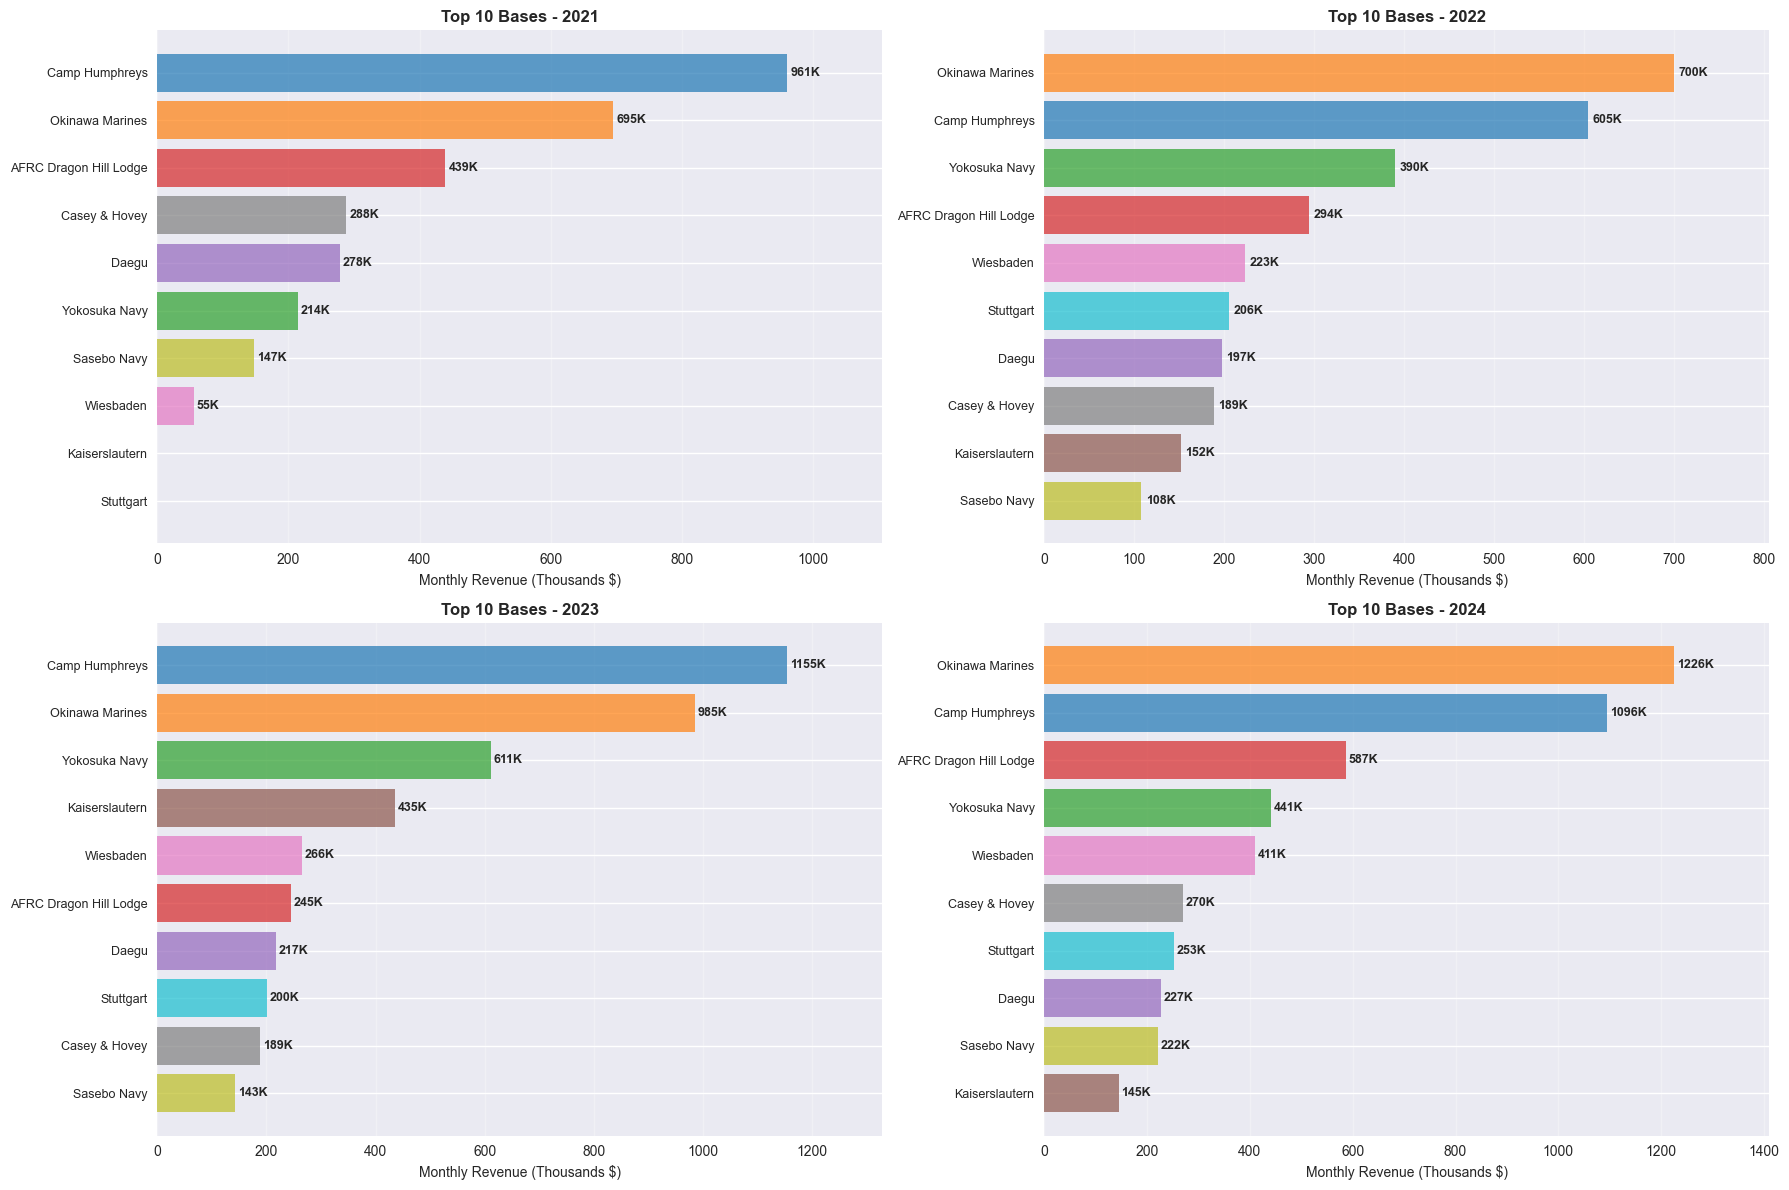

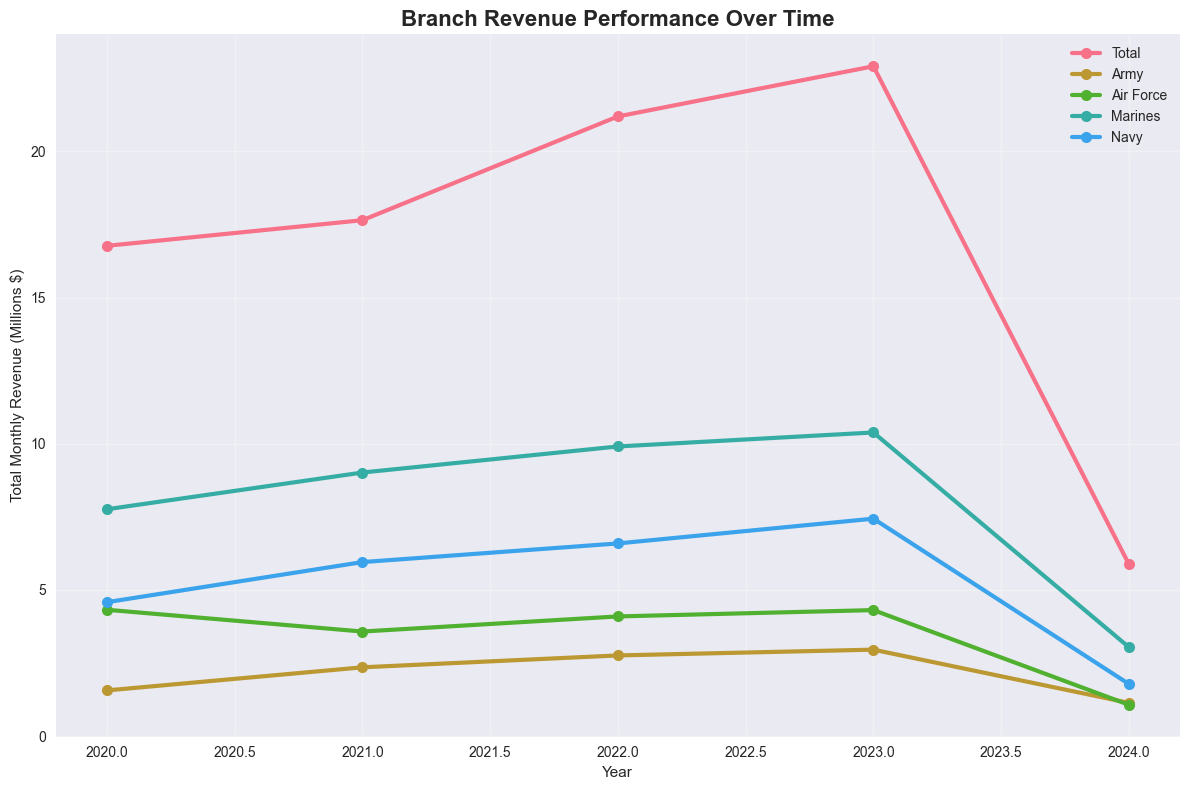


Analysis complete!


In [14]:
# Load and clean data
print("Loading and cleaning data...")
df = load_and_clean_data('data/Financial Statements/Financial Statements Format-4.csv')
df = create_monthly_revenue_column(df)

# Generate summary statistics
generate_summary_statistics(df)

# Create visualizations
print("\nGenerating visualizations...")

# Plot 1: Revenue by branch and region
branch_revenue, region_revenue, branch_avg, region_avg = plot_revenue_by_branch_region(df)

# Plot 2: Top bases over time (only predefined top 10)
top_bases_data = plot_top_bases_over_time(df)

# Plot 3: Branch performance over time
branch_year_revenue = plot_branch_performance_over_time(df)
print("\nAnalysis complete!")